In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

2026-04-03 16:27:05.668559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775233625.867809      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775233625.927076      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775233626.397299      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775233626.397342      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775233626.397345      55 computation_placer.cc:177] computation placer alr

In [2]:
CSV_PATH = "/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-22-2018.csv"

SAMPLE_SIZE = None   
BATCH_SIZE = 512
EPOCHS = 35
LEARNING_RATE = 1e-3
RANDOM_STATE = 42

In [3]:
def load_and_clean_data(csv_path, sample_size=None):
    print(f"Loading data from {csv_path}...")

    df = pd.read_csv(csv_path, low_memory=False)

    if 'Dst Port' in df.columns:
        df = df[df['Dst Port'] != 'Dst Port']

    df.columns = df.columns.str.strip()

    if 'Label' in df.columns:
        df['Label'] = df['Label'].astype(str).str.strip()

    cols_to_numeric = df.columns.drop('Label')
    df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    df.dropna(axis=1, how='all', inplace=True)

    print("Replacing NaN values with column means...")
    for col in df.columns.drop('Label'):
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mean())

    df.dropna(inplace=True)

    if sample_size is not None and sample_size < len(df):
        print(f"Sampling {sample_size} rows...")
        df = df.sample(n=sample_size, random_state=RANDOM_STATE)

    print(f"\nFinal Shape: {df.shape}")
    print("\nClass Distribution:")
    print(df['Label'].value_counts())

    return df

In [4]:
def reduce_benign_in_training(X_train, y_train, benign_label='Benign', random_state=42):
    #use only if necessary-bad results, skipped in autoencoders
    X_train_df = pd.DataFrame(X_train)
    y_train_series = pd.Series(y_train, name='Label')

    train_df = X_train_df.copy()
    train_df['Label'] = y_train_series.values

    benign_df = train_df[train_df['Label'] == benign_label]
    attack_df = train_df[train_df['Label'] != benign_label]

    benign_count = len(benign_df)
    attack_count = len(attack_df)

    print("\n========== TRAIN BENIGN REDUCTION CHECK ==========")
    print(f"Benign count in train : {benign_count}")
    print(f"Attack count in train : {attack_count}")
    print(f"2 x attack count      : {2 * attack_count}")

    if benign_count > 1000000 * attack_count:
        target_benign_count = 1000000 * attack_count
        print(f"\nReducing Benign from {benign_count} -> {target_benign_count}")

        benign_df = benign_df.sample(
            n=target_benign_count,
            random_state=random_state
        )

        reduced_train_df = pd.concat([benign_df, attack_df], axis=0)
        reduced_train_df = reduced_train_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    else:
        print("\nNo reduction needed. Benign is already <= 2x attack traffic.")
        reduced_train_df = train_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    X_train_reduced = reduced_train_df.drop(columns=['Label']).values
    y_train_reduced = reduced_train_df['Label'].values

    print("\nReduced Training Distribution:")
    print(pd.Series(y_train_reduced).value_counts())

    return X_train_reduced, y_train_reduced

In [5]:
def build_supervised_autoencoder(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input_features")

    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    latent = layers.Dense(32, activation='relu', name='latent_space')(x)

    d = layers.Dense(64, activation='relu')(latent)
    d = layers.BatchNormalization()(d)
    d = layers.Dropout(0.2)(d)

    d = layers.Dense(128, activation='relu')(d)
    d = layers.BatchNormalization()(d)
    d = layers.Dropout(0.2)(d)

    reconstruction_output = layers.Dense(
        input_dim,
        activation='linear',
        name='reconstruction_output'
    )(d)

    c = layers.Dense(32, activation='relu')(latent)
    c = layers.Dropout(0.2)(c)

    classification_output = layers.Dense(
        1,
        activation='sigmoid',
        name='classification_output'
    )(c)

    model = keras.Model(
        inputs=inputs,
        outputs=[reconstruction_output, classification_output],
        name='supervised_autoencoder'
    )

    return model

In [6]:
if not os.path.exists(CSV_PATH):
    print(f"ERROR: File '{CSV_PATH}' not found.")
else:

    df = load_and_clean_data(CSV_PATH, sample_size=SAMPLE_SIZE)

    benign_label = 'Benign'  

    df['BinaryLabel'] = df['Label'].apply(lambda x: 0 if x == benign_label else 1)

    X = df.drop(columns=['Label', 'BinaryLabel']).values.astype(np.float32)
    y_string = df['Label'].values
    y_binary = df['BinaryLabel'].values.astype(np.int32)

    print(f"\nTotal rows: {len(df)}")
    print(f"Total features: {X.shape[1]}")


    # TRAIN / TEMP SPLIT

    X_train_full, X_temp, y_train_full_str, y_temp_str, y_train_full_bin, y_temp_bin = train_test_split(
        X, y_string, y_binary,
        test_size=0.3,
        random_state=RANDOM_STATE,
        stratify=y_binary
    )


    # VAL / TEST SPLIT

    X_val, X_test, y_val_str, y_test_str, y_val_bin, y_test_bin = train_test_split(
        X_temp, y_temp_str, y_temp_bin,
        test_size=0.5,
        random_state=RANDOM_STATE,
        stratify=y_temp_bin
    )

    print("\n========== BEFORE TRAIN REDUCTION ==========")
    print("Train distribution:")
    print(pd.Series(y_train_full_str).value_counts())

    print("\nValidation distribution:")
    print(pd.Series(y_val_str).value_counts())

    print("\nTest distribution:")
    print(pd.Series(y_test_str).value_counts())

    # REDUCE BENIGN ONLY IN TRAIN (if necessary)
    '''
    X_train, y_train_str = reduce_benign_in_training(
        X_train_full,
        y_train_full_str,
        benign_label=benign_label,
        random_state=RANDOM_STATE
    )
    '''
    # SKIP BENIGN REDUCTION IN AUTOENCODERS
    X_train = X_train_full
    y_train_str = y_train_full_str
    
    y_train_bin = np.array([0 if lbl == benign_label else 1 for lbl in y_train_str], dtype=np.int32)

    print("\n========== AFTER TRAIN REDUCTION ==========")
    print(pd.Series(y_train_str).value_counts())


    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_val_scaled   = scaler.transform(X_val).astype(np.float32)
    X_test_scaled  = scaler.transform(X_test).astype(np.float32)

    print("\nScaled shapes:")
    print("X_train_scaled:", X_train_scaled.shape)
    print("X_val_scaled  :", X_val_scaled.shape)
    print("X_test_scaled :", X_test_scaled.shape)

Loading data from /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-22-2018.csv...
Replacing NaN values with column means...

Final Shape: (1048575, 79)

Class Distribution:
Label
Benign              1048213
Brute Force -Web        249
Brute Force -XSS         79
SQL Injection            34
Name: count, dtype: int64

Total rows: 1048575
Total features: 78

========== BEFORE TRAIN REDUCTION ==========
Train distribution:
Benign              733749
Brute Force -Web       185
Brute Force -XSS        45
SQL Injection           23
Name: count, dtype: int64

Validation distribution:
Benign              157232
Brute Force -Web        33
Brute Force -XSS        14
SQL Injection            7
Name: count, dtype: int64

Test distribution:
Benign              157232
Brute Force -Web        31
Brute Force -XSS        20
SQL Injection            4
Name: count, dtype: int64

========== AFTER TRAIN REDUCTION ==========
Benign              733749
Brute Force -Web       185
Brute Force -XSS    

In [7]:

    # BUILD MODEL

    input_dim = X_train_scaled.shape[1]
    model = build_supervised_autoencoder(input_dim)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss={
            'reconstruction_output': keras.losses.Huber(),
            'classification_output': 'binary_crossentropy'
        },
        loss_weights={
            'reconstruction_output': 0.5,
            'classification_output': 1.5
        },
        metrics={
            'classification_output': ['accuracy']
        }
    )

    model.summary()

I0000 00:00:1775233672.634499      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "supervised_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 78)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     10,112 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_space        │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      2,112 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      8,320 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      1,056 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction_out… │ (None, 78)        │     10,062 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 1)         │         33 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,567 (170.18 KB)

 Trainable params: 42,799 (167.18 KB)

 Non-trainable params: 768 (3.00 KB)

In [8]:

    # CALLBACKS

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_classification_output_accuracy',
        mode='max',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_classification_output_accuracy',
        mode='max',
        factor=0.5,
        patience=3,
        verbose=1
    )

    # TRAIN

    print("\nStarting Supervised Autoencoder Training...")

    history = model.fit(
        X_train_scaled,
        {
            'reconstruction_output': X_train_scaled,
            'classification_output': y_train_bin
        },
        validation_data=(
            X_val_scaled,
            {
                'reconstruction_output': X_val_scaled,
                'classification_output': y_val_bin
            }
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    print("\nTraining Complete.")


Starting Supervised Autoencoder Training...
Epoch 1/35


I0000 00:00:1775233678.780075     127 service.cc:152] XLA service 0x7ecdb8007520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775233678.780113     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775233679.559316     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


  46/1434 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - classification_output_accuracy: 0.7152 - classification_output_loss: 0.5669 - loss: 1.0703 - reconstruction_output_loss: 0.4398

I0000 00:00:1775233683.087245     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1434/1434 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - classification_output_accuracy: 0.9786 - classification_output_loss: 0.0564 - loss: 0.1432 - reconstruction_output_loss: 0.1170 - val_classification_output_accuracy: 0.9998 - val_classification_output_loss: 0.0017 - val_loss: 0.0153 - val_reconstruction_output_loss: 0.0261 - learning_rate: 0.0010
Epoch 2/35
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - classification_output_accuracy: 0.9997 - classification_output_loss: 0.0018 - loss: 0.0179 - reconstruction_output_loss: 0.0304 - val_classification_output_accuracy: 0.9998 - val_classification_output_loss: 0.0013 - val_loss: 0.0112 - val_reconstruction_output_loss: 0.0191 - learning_rate: 0.0010
Epoch 3/35
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - classification_output_accuracy: 0.9998 - classification_output_loss: 0.0015 - loss: 0.0152 - reconstruction_output_loss: 0.0259 - val_classification_output_accuracy: 0.9999 - val_classification_output_loss: 0.0011 - val_loss: 0.0094 - val_reconst

In [9]:

    # VALIDATION EVALUATION

    print("\nRunning validation predictions...")

    val_recon, val_probs = model.predict(X_val_scaled, batch_size=BATCH_SIZE)

    val_probs = val_probs.ravel()
    val_preds = (val_probs >= 0.5).astype(int)

    macro_f1_val = f1_score(y_val_bin, val_preds, average='macro')
    weighted_f1_val = f1_score(y_val_bin, val_preds, average='weighted')

  
    print("SUPERVISED AUTOENCODER VALIDATION")

    print(f"Validation Macro F1   : {macro_f1_val:.4f}")
    print(f"Validation Weighted F1: {weighted_f1_val:.4f}")


Running validation predictions...
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
SUPERVISED AUTOENCODER VALIDATION
Validation Macro F1   : 0.9649
Validation Weighted F1: 1.0000


In [10]:

    # TEST EVALUATION

    print("\nRunning final test predictions...")

    test_recon, test_probs = model.predict(X_test_scaled, batch_size=BATCH_SIZE)

    test_probs = test_probs.ravel()
    test_preds = (test_probs >= 0.5).astype(int)

    macro_f1 = f1_score(y_test_bin, test_preds, average='macro')
    weighted_f1 = f1_score(y_test_bin, test_preds, average='weighted')


    print("     FINAL EVALUATION: SUPERVISED AUTOENCODER     ")
 
    print(f"Macro F1 Score   : {macro_f1:.4f}")
    print(f"Weighted F1 Score: {weighted_f1:.4f}\n")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test_bin, test_preds))

    print("\nDetailed Classification Report:")
    print(classification_report(
        y_test_bin,
        test_preds,
        target_names=['Benign', 'Malicious'],
        digits=4
    ))


Running final test predictions...
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
     FINAL EVALUATION: SUPERVISED AUTOENCODER     
Macro F1 Score   : 0.9867
Weighted F1 Score: 1.0000

Confusion Matrix:
[[157229      3]
 [     0     55]]

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000    157232
   Malicious     0.9483    1.0000    0.9735        55

    accuracy                         1.0000    157287
   macro avg     0.9741    1.0000    0.9867    157287
weighted avg     1.0000    1.0000    1.0000    157287



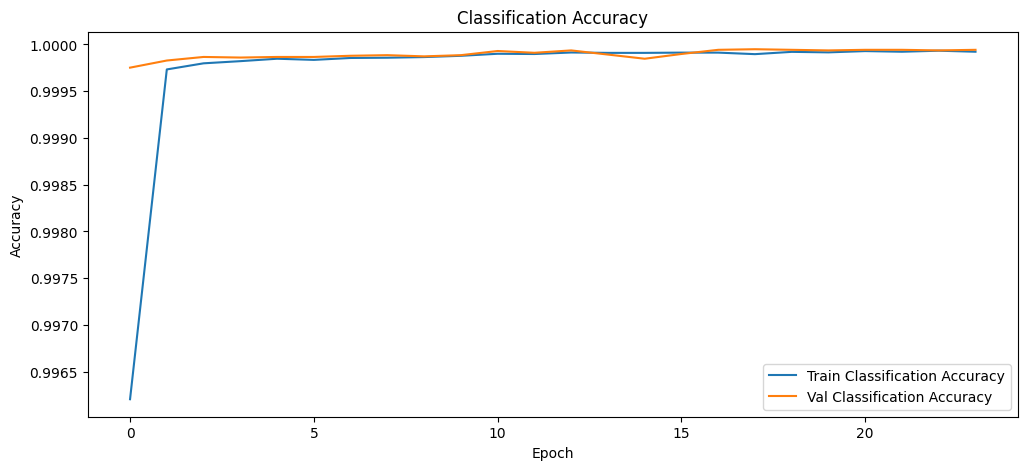

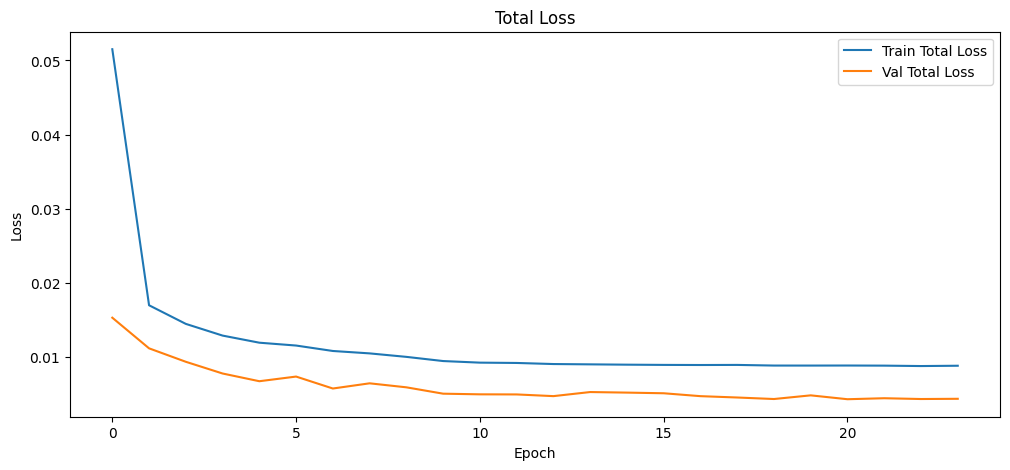

In [11]:

    # PLOT TRAINING HISTORY
    
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['classification_output_accuracy'], label='Train Classification Accuracy')
    plt.plot(history.history['val_classification_output_accuracy'], label='Val Classification Accuracy')
    plt.title("Classification Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(history.history['loss'], label='Train Total Loss')
    plt.plot(history.history['val_loss'], label='Val Total Loss')
    plt.title("Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [12]:

    # SAVE MODEL AND SCALER

    model.save("/kaggle/working/supervised_autoencoder.keras")
    joblib.dump(scaler, "/kaggle/working/scaler.pkl")

    feature_names = list(df.drop(columns=['Label', 'BinaryLabel']).columns)
    joblib.dump(feature_names, "/kaggle/working/feature_names.pkl")

    print("\n Model, scaler, and feature names saved.")


 Model, scaler, and feature names saved.


In [13]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score


print("Evaluating on train set to complete the table...")
train_recon, train_probs = model.predict(X_train_scaled, batch_size=BATCH_SIZE)
train_probs = train_probs.ravel()
train_preds = (train_probs >= 0.5).astype(int)

train_acc = accuracy_score(y_train_bin, train_preds)
val_acc = accuracy_score(y_val_bin, val_preds) 
test_acc = accuracy_score(y_test_bin, test_preds) 

train_f1 = f1_score(y_train_bin, train_preds, average='macro')
val_f1 = macro_f1_val   
test_f1 = macro_f1      

total_instances = 1048575
benign_count = 1048213
malicious_count = 362

benign_pct = (benign_count / total_instances) * 100
malicious_pct = (malicious_count / total_instances) * 100

summary_data = {
    "Attack Included": ["Brute Force -Web, Brute Force -XSS, SQL Injection"],
    "Train Accuracy": [f"{train_acc:.4f}"],
    "Val Accuracy": [f"{val_acc:.4f}"],
    "Test Accuracy": [f"{test_acc:.4f}"],
    "Train F1 (Macro)": [f"{train_f1:.4f}"],
    "Val F1 (Macro)": [f"{val_f1:.4f}"],
    "Test F1 (Macro)": [f"{test_f1:.4f}"],
    "Total Instances": [f"{total_instances:,}"],
    "Split (Train/Val/Test)": ["70% / 15% / 15%"],
    "Benign %": [f"{benign_pct:.4f}%"],
    "Malicious %": [f"{malicious_pct:.4f}%"]
}

summary_df = pd.DataFrame(summary_data)

display(summary_df)

Evaluating on train set to complete the table...
1434/1434 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


,Attack Included,Train Accuracy,Val Accuracy,Test Accuracy,Train F1 (Macro),Val F1 (Macro),Test F1 (Macro),Total Instances,Split (Train/Val/Test),Benign %,Malicious %
0,"Brute Force -Web, Brute Force -XSS, SQL Injection",1.0000,0.9999,1.0000,0.9774,0.9649,0.9867,"1,048,575",70% / 15% / 15%,99.9655%,0.0345%


In [14]:
import json
import joblib
import numpy as np
from sklearn.preprocessing import LabelEncoder


feature_names = df.drop(columns=['Label', 'BinaryLabel']).columns.tolist()

print(f"Extracted {len(feature_names)} features.")


le = LabelEncoder()
le.classes_ = np.array(['Benign', 'Malicious'])


with open('model_columns.json', 'w') as f:
    json.dump(feature_names, f)
print("Saved: model_columns.json")

joblib.dump(scaler, 'scaler.joblib')
print("Saved: scaler.joblib")

joblib.dump(le, 'label_encoder.joblib')
print("Saved: label_encoder.joblib")

model.save('ids_model.keras')
print("Saved: ids_model.keras")

Extracted 78 features.
Saved: model_columns.json
Saved: scaler.joblib
Saved: label_encoder.joblib
Saved: ids_model.keras
